# NurseAssist Triage ML Notebook

# 1. Notebook title and project description

## NurseAssist Triage
## Supervised Machine Learning Model for Prioritising Patient Appointment Calls


Goal:
Build a supervised classification model that predicts patient triage priority
from patient information such as age, sex, chief complaint, pain, mental status,
vitals, and injury status.

Dataset:
Kaggle - Emergency Service - Triage Application

Target:
Preferably KTAS_expert if available.

Priority mapping:
- KTAS 1-2 = High priority
- KTAS 3   = Medium priority
- KTAS 4-5 = Low priority

# 2. Import libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

# 3. Load the dataset

In [7]:
DATA_PATH = "data.csv"

df = pd.read_csv(DATA_PATH, sep=";", encoding="latin1")

df.head()

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,...,BT,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min,mistriage
0,2,2,71,3,3,2,right ocular pain,1,1,2,...,36.6,100,2,Corneal abrasion,1,4,2,86,"5,00",1
1,1,1,56,12,3,2,right forearm burn,1,1,2,...,36.5,NaN,4,"Burn of hand, firts degree dorsum",1,5,4,64,"3,95",1
2,2,1,68,8,2,2,"arm pain, Lt",1,1,2,...,36.6,98,4,"Fracture of surgical neck of humerus, closed",2,5,4,862,"1,00",1
3,1,2,71,8,1,1,ascites tapping,1,1,3,...,36.5,NaN,4,Alcoholic liver cirrhosis with ascites,1,5,6,108,"9,83",1
4,1,2,58,4,3,1,"distension, abd",1,1,3,...,36.5,NaN,4,Ascites,1,5,8,109,"6,60",1


In [8]:
df.shape

(1267, 24)

In [9]:
df.columns.tolist()

['Group',
 'Sex',
 'Age',
 'Patients number per hour',
 'Arrival mode',
 'Injury',
 'Chief_complain',
 'Mental',
 'Pain',
 'NRS_pain',
 'SBP',
 'DBP',
 'HR',
 'RR',
 'BT',
 'Saturation',
 'KTAS_RN',
 'Diagnosis in ED',
 'Disposition',
 'KTAS_expert',
 'Error_group',
 'Length of stay_min',
 'KTAS duration_min',
 'mistriage']

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1267 entries, 0 to 1266
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Group                     1267 non-null   int64
 1   Sex                       1267 non-null   int64
 2   Age                       1267 non-null   int64
 3   Patients number per hour  1267 non-null   int64
 4   Arrival mode              1267 non-null   int64
 5   Injury                    1267 non-null   int64
 6   Chief_complain            1267 non-null   str  
 7   Mental                    1267 non-null   int64
 8   Pain                      1267 non-null   int64
 9   NRS_pain                  1267 non-null   str  
 10  SBP                       1267 non-null   str  
 11  DBP                       1267 non-null   str  
 12  HR                        1267 non-null   str  
 13  RR                        1267 non-null   str  
 14  BT                        1267 non-null   str  
 15

# 4. Explore the dataset

In [13]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Group,1267.0,NaN,NaN,NaN,1.456985,0.498343,1.0,1.0,1.0,2.0,2.0
Sex,1267.0,NaN,NaN,NaN,1.521705,0.499726,1.0,1.0,2.0,2.0,2.0
Age,1267.0,NaN,NaN,NaN,54.423836,19.725033,16.0,37.0,57.0,71.0,96.0
Patients number per hour,1267.0,NaN,NaN,NaN,7.519337,3.160563,1.0,5.0,7.0,10.0,17.0
Arrival mode,1267.0,NaN,NaN,NaN,2.820837,0.807904,1.0,2.0,3.0,3.0,7.0
Injury,1267.0,NaN,NaN,NaN,1.192581,0.394482,1.0,1.0,1.0,1.0,2.0
Chief_complain,1267,417,abd pain,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mental,1267.0,NaN,NaN,NaN,1.105762,0.447768,1.0,1.0,1.0,1.0,4.0
Pain,1267.0,NaN,NaN,NaN,0.563536,0.496143,0.0,0.0,1.0,1.0,1.0
NRS_pain,1267,11,#BOÞ!,556,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Saturation         688
Diagnosis in ED      2
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
target_like_columns = [
    col for col in df.columns 
    if "KTAS" in col.upper() or "triage" in col.lower() or "priority" in col.lower()
]

target_like_columns

['KTAS_RN', 'KTAS_expert', 'KTAS duration_min', 'mistriage']

# 5. Select the target column

In [20]:
# We prefer KTAS_expert because it represents expert triage judgement.

target_col = "KTAS_expert"
df[target_col].value_counts(dropna=False).sort_index()


KTAS_expert
1     26
2    220
3    487
4    459
5     75
Name: count, dtype: int64

# 6. Clean the target column

In [22]:
df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

df = df.dropna(subset=[target_col])

df[target_col] = df[target_col].astype(int)

df[target_col].value_counts().sort_index()

df = df[df[target_col].isin([1, 2, 3, 4, 5])]

df[target_col].value_counts().sort_index()

KTAS_expert
1     26
2    220
3    487
4    459
5     75
Name: count, dtype: int64

# 7. Create the 3-class priority label

In [23]:
def map_ktas_to_priority(ktas):
    if ktas in [1, 2]:
        return "High"
    elif ktas == 3:
        return "Medium"
    elif ktas in [4, 5]:
        return "Low"
    else:
        return np.nan

df["priority_label"] = df[target_col].apply(map_ktas_to_priority)

df["priority_label"].value_counts()

priority_label
Low       534
Medium    487
High      246
Name: count, dtype: int64

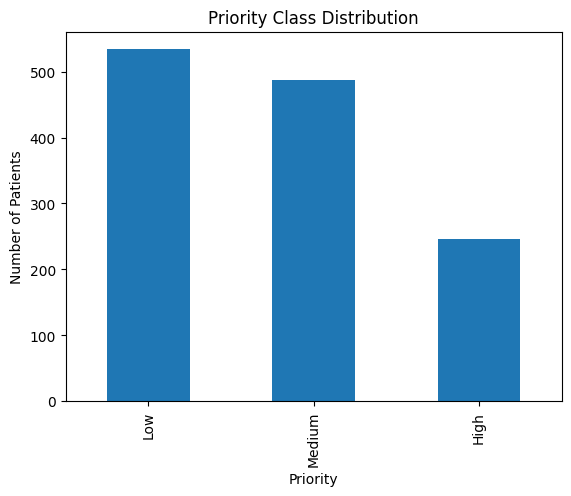

In [24]:
df["priority_label"].value_counts().plot(kind="bar")
plt.title("Priority Class Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Patients")
plt.show()

# 8. Remove leakage columns

We must remove columns that would not be available during a real appointment call or that directly reveal the answer.

In [27]:
leakage_columns = ['KTAS_RN',
 'Diagnosis in ED',
 'Disposition',
 'KTAS_expert',
 'Error_group',
 'Length of stay_min',
 'KTAS duration_min',
 'mistriage']

leakage_columns

['KTAS_RN',
 'Diagnosis in ED',
 'Disposition',
 'KTAS_expert',
 'Error_group',
 'Length of stay_min',
 'KTAS duration_min',
 'mistriage']

In [28]:
X = df.drop(columns=leakage_columns + ["priority_label"], errors="ignore")
y = df["priority_label"]

X.head()

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,SBP,DBP,HR,RR,BT,Saturation
0,2,2,71,3,3,2,right ocular pain,1,1,2,160,100,84,18,36.6,100
1,1,1,56,12,3,2,right forearm burn,1,1,2,137,75,60,20,36.5,NaN
2,2,1,68,8,2,2,"arm pain, Lt",1,1,2,130,80,102,20,36.6,98
3,1,2,71,8,1,1,ascites tapping,1,1,3,139,94,88,20,36.5,NaN
4,1,2,58,4,3,1,"distension, abd",1,1,3,91,67,93,18,36.5,NaN


Check remaining features:

In [29]:
X.columns.tolist()

['Group',
 'Sex',
 'Age',
 'Patients number per hour',
 'Arrival mode',
 'Injury',
 'Chief_complain',
 'Mental',
 'Pain',
 'NRS_pain',
 'SBP',
 'DBP',
 'HR',
 'RR',
 'BT',
 'Saturation']

In [30]:
candidate_features =  [
 'Sex',
 'Age',
 'Patients number per hour',
 'Arrival mode',
 'Injury',
 'Chief_complain',
 'Mental',
 'Pain',
 'NRS_pain',
 'SBP',
 'DBP',
 'HR',
 'RR',
 'BT',
 'Saturation']

In [33]:
X = X[candidate_features]

X.head()

,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,SBP,DBP,HR,RR,BT,Saturation
0,2,71,3,3,2,right ocular pain,1,1,2,160,100,84,18,36.6,100
1,1,56,12,3,2,right forearm burn,1,1,2,137,75,60,20,36.5,NaN
2,1,68,8,2,2,"arm pain, Lt",1,1,2,130,80,102,20,36.6,98
3,2,71,8,1,1,ascites tapping,1,1,3,139,94,88,20,36.5,NaN
4,2,58,4,3,1,"distension, abd",1,1,3,91,67,93,18,36.5,NaN


# 9. Basic data cleaning

In [34]:
# Replace blank strings with missing values:
X = X.replace(r"^\s*$", np.nan, regex=True)

In [35]:
# Check missing values again:

X.isnull().sum().sort_values(ascending=False)

Saturation                  688
Sex                           0
Age                           0
Patients number per hour      0
Arrival mode                  0
Injury                        0
Chief_complain                0
Mental                        0
Pain                          0
NRS_pain                      0
SBP                           0
DBP                           0
HR                            0
RR                            0
BT                            0
dtype: int64

In [36]:
missing_percentage = X["Saturation"].isnull().mean() * 100
missing_percentage

np.float64(54.30149960536701)

In [38]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_features, categorical_features

/var/folders/4j/q6y7h_7s19gg8mcchpzn3r4c0000gn/T/ipykernel_66442/2541183862.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


(['Sex',
  'Age',
  'Patients number per hour',
  'Arrival mode',
  'Injury',
  'Mental',
  'Pain'],
 ['Chief_complain', 'NRS_pain', 'SBP', 'DBP', 'HR', 'RR', 'BT', 'Saturation'])

Leaving Saturation because Oxygen saturation is very relevant for identifying high-priority patients.

# 10. Train-test split

In [39]:
# Use stratification so the class distribution is preserved.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(priority_label
 Low       0.421520
 Medium    0.384008
 High      0.194472
 Name: proportion, dtype: float64,
 priority_label
 Low       0.421260
 Medium    0.385827
 High      0.192913
 Name: proportion, dtype: float64)

# 11. Build preprocessing pipeline

In [43]:
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# 12. Define Models

In [44]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

# 13. Train and evaluate all models

In [45]:
results = []

trained_models = {}

for model_name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    high_recall = recall_score(
        y_test,
        y_pred,
        labels=["High"],
        average=None,
        zero_division=0
    )[0]
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision Weighted": precision,
        "Recall Weighted": recall,
        "F1 Weighted": f1,
        "High Priority Recall": high_recall
    })
    
    trained_models[model_name] = clf

In [46]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="High Priority Recall", ascending=False)

,Model,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,High Priority Recall
0,Logistic Regression,0.669291,0.671210,0.669291,0.669607,0.653061
3,Gradient Boosting,0.696850,0.714854,0.696850,0.696371,0.551020
1,Decision Tree,0.637795,0.642460,0.637795,0.637959,0.530612
2,Random Forest,0.673228,0.691015,0.673228,0.671574,0.489796


# 14. Print classification reports

In [47]:
for model_name, clf in trained_models.items():
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    
    y_pred = clf.predict(X_test)
    
    print(classification_report(y_test, y_pred, zero_division=0))

Logistic Regression
              precision    recall  f1-score   support

        High       0.58      0.65      0.62        49
         Low       0.72      0.72      0.72       107
      Medium       0.66      0.62      0.64        98

    accuracy                           0.67       254
   macro avg       0.65      0.67      0.66       254
weighted avg       0.67      0.67      0.67       254

Decision Tree
              precision    recall  f1-score   support

        High       0.53      0.53      0.53        49
         Low       0.71      0.63      0.67       107
      Medium       0.62      0.70      0.66        98

    accuracy                           0.64       254
   macro avg       0.62      0.62      0.62       254
weighted avg       0.64      0.64      0.64       254

Random Forest
              precision    recall  f1-score   support

        High       0.83      0.49      0.62        49
         Low       0.71      0.71      0.71       107
      Medium       0.60    

# 15. Confusion matrix for each model

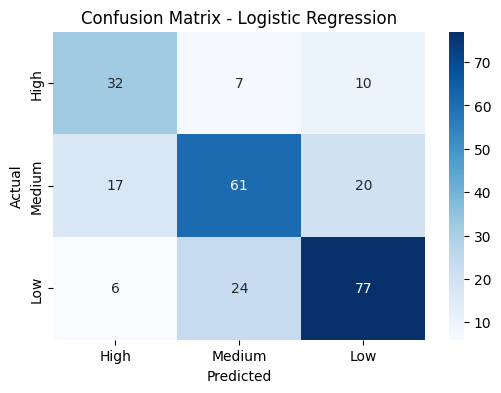

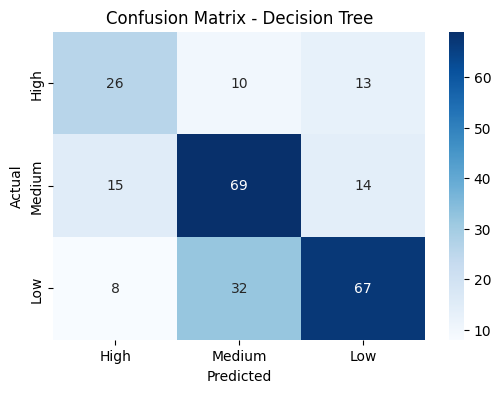

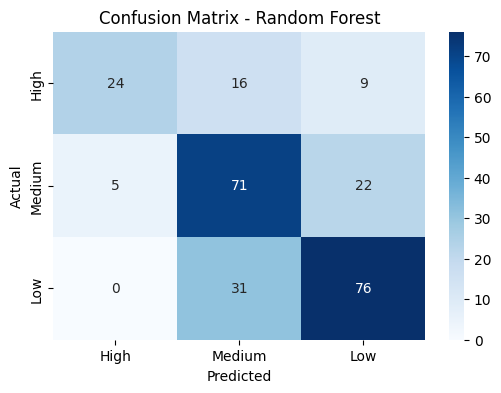

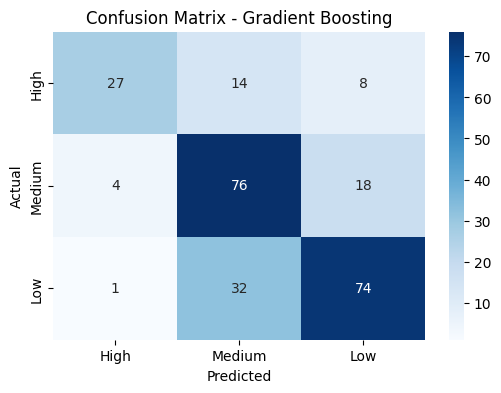

In [48]:
labels = ["High", "Medium", "Low"]

for model_name, clf in trained_models.items():
    y_pred = clf.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=labels,
        yticklabels=labels,
        cmap="Blues"
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# 16. Choose the best model

In [49]:
best_model_row = results_df.sort_values(
    by="High Priority Recall",
    ascending=False
).iloc[0]

best_model_name = best_model_row["Model"]
best_model = trained_models[best_model_name]

best_model_name, best_model_row

('Logistic Regression',
 Model                   Logistic Regression
 Accuracy                           0.669291
 Precision Weighted                  0.67121
 Recall Weighted                    0.669291
 F1 Weighted                        0.669607
 High Priority Recall               0.653061
 Name: 0, dtype: object)

# 17. Save the best model

In [50]:
MODEL_PATH = "nurseassist_triage_model.joblib"

joblib.dump(best_model, MODEL_PATH)

MODEL_PATH

'nurseassist_triage_model.joblib'

In [51]:
# Save the feature list

feature_info = {
    "features": X.columns.tolist(),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target": "priority_label",
    "source_target": target_col,
    "best_model": best_model_name
}

joblib.dump(feature_info, "nurseassist_feature_info.joblib")

['nurseassist_feature_info.joblib']

# 18. Test loading the model

In [52]:
loaded_model = joblib.load("nurseassist_triage_model.joblib")

sample_patient = X_test.iloc[[0]]

sample_patient

,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,SBP,DBP,HR,RR,BT,Saturation
558,1,68,5,3,1,vomiting,1,1,5,167,80,74,18,36.7,NaN


In [53]:
loaded_model.predict(sample_patient)

array(['Medium'], dtype=object)

In [55]:
if hasattr(loaded_model.named_steps["model"], "predict_proba"):
    probabilities = loaded_model.predict_proba(sample_patient)
    classes = loaded_model.named_steps["model"].classes_
    
    dff = pd.DataFrame(probabilities, columns=classes)

    print("Predicted probabilities:")
    print(dff)

Predicted probabilities:
       High       Low    Medium
0  0.094102  0.196811  0.709088
